In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from category_encoders import TargetEncoder
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error,root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

### Data Cleaning

In [12]:
data = pd.read_csv('yield_df.csv')
data.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [13]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28242 non-null  int64  
 1   Area                           28242 non-null  str    
 2   Item                           28242 non-null  str    
 3   Year                           28242 non-null  int64  
 4   hg/ha_yield                    28242 non-null  int64  
 5   average_rain_fall_mm_per_year  28242 non-null  float64
 6   pesticides_tonnes              28242 non-null  float64
 7   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(3), str(2)
memory usage: 1.7 MB


In [14]:
data.drop(columns = 'Unnamed: 0', inplace = True)

### EDA

In [15]:
data.head()

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [16]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Area                           28242 non-null  str    
 1   Item                           28242 non-null  str    
 2   Year                           28242 non-null  int64  
 3   hg/ha_yield                    28242 non-null  int64  
 4   average_rain_fall_mm_per_year  28242 non-null  float64
 5   pesticides_tonnes              28242 non-null  float64
 6   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(2), str(2)
memory usage: 1.5 MB


In [17]:
data['Item'].value_counts()

Item
Potatoes                4276
Maize                   4121
Wheat                   3857
Rice, paddy             3388
Soybeans                3223
Sorghum                 3039
Sweet potatoes          2890
Cassava                 2045
Yams                     847
Plantains and others     556
Name: count, dtype: int64

In [18]:
data['Area'].value_counts()

Area
India         4048
Brazil        2277
Mexico        1472
Pakistan      1449
Australia      966
              ... 
Latvia          42
Belgium         39
Bahrain         29
Sudan           28
Montenegro      24
Name: count, Length: 101, dtype: int64

In [19]:
data['pesticides_tonnes'].value_counts()

pesticides_tonnes
1597.00     720
34468.93    704
79821.18    462
26857.00    364
75000.00    176
           ... 
12.12         1
16.25         1
10.45         1
12.59         1
9.84          1
Name: count, Length: 1673, dtype: int64

In [20]:
data['avg_temp'].value_counts()

avg_temp
27.20    90
27.03    84
27.01    83
25.44    81
27.23    81
         ..
10.83     2
9.38      2
11.19     2
8.08      2
27.86     1
Name: count, Length: 1831, dtype: int64

In [21]:
data['Year'].value_counts()

Year
2012    1260
2013    1259
2010    1245
2011    1245
2008    1244
2006    1243
2007    1242
2009    1242
2005    1235
2004    1234
2000    1230
2001    1229
2002    1228
1997    1224
1998    1224
1993    1223
1999    1223
1995    1222
1996    1222
1994    1221
1992    1219
1990    1164
1991    1164
Name: count, dtype: int64

In [22]:
numeric_cols = data.select_dtypes(include = ['int64','float64']).columns
numeric_cols

Index(['Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year',
       'pesticides_tonnes', 'avg_temp'],
      dtype='str')

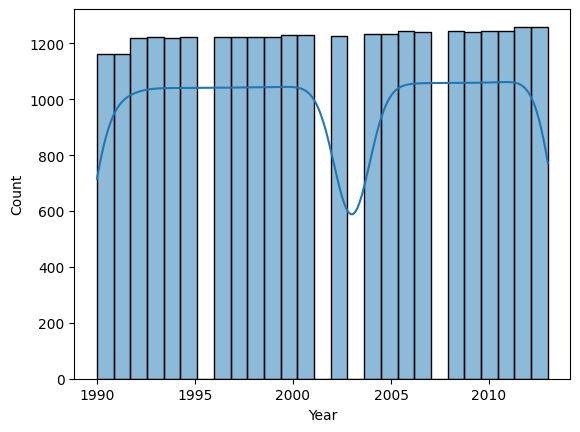

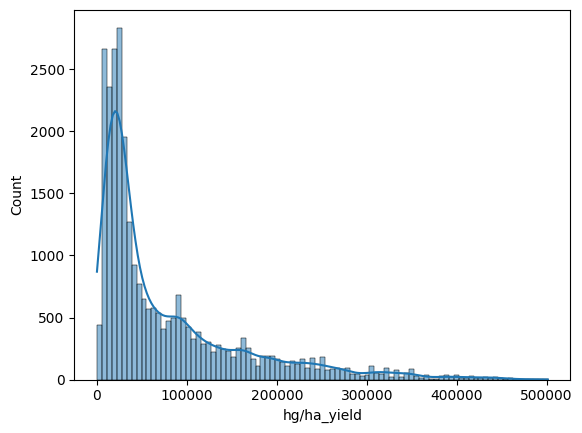

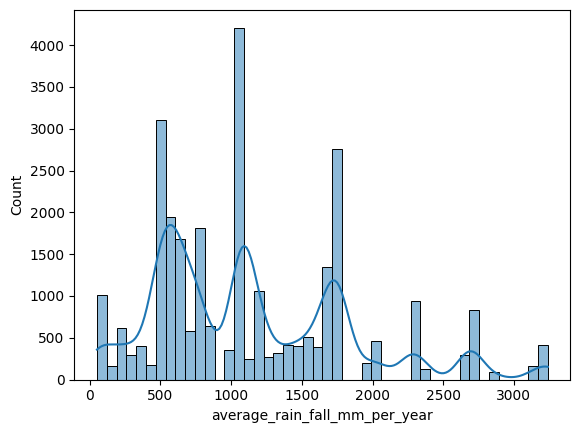

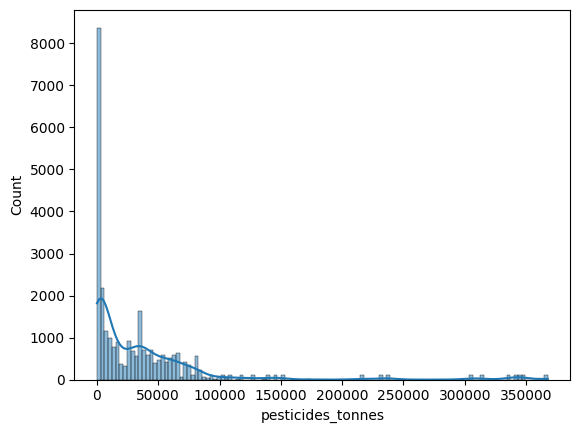

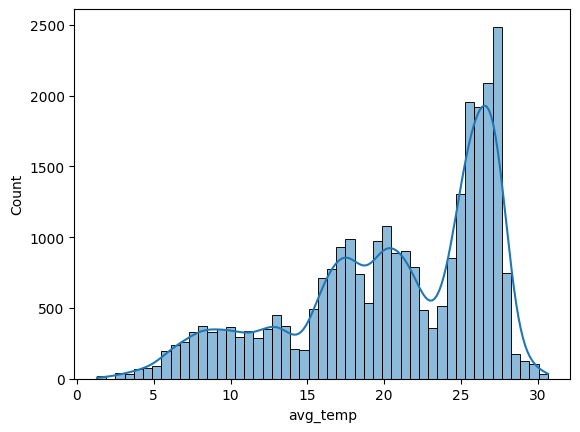

In [23]:
for col in numeric_cols:
    plt.figure()
    sns.histplot(data[col], kde = True)
    plt.show()

### Linear Seperability

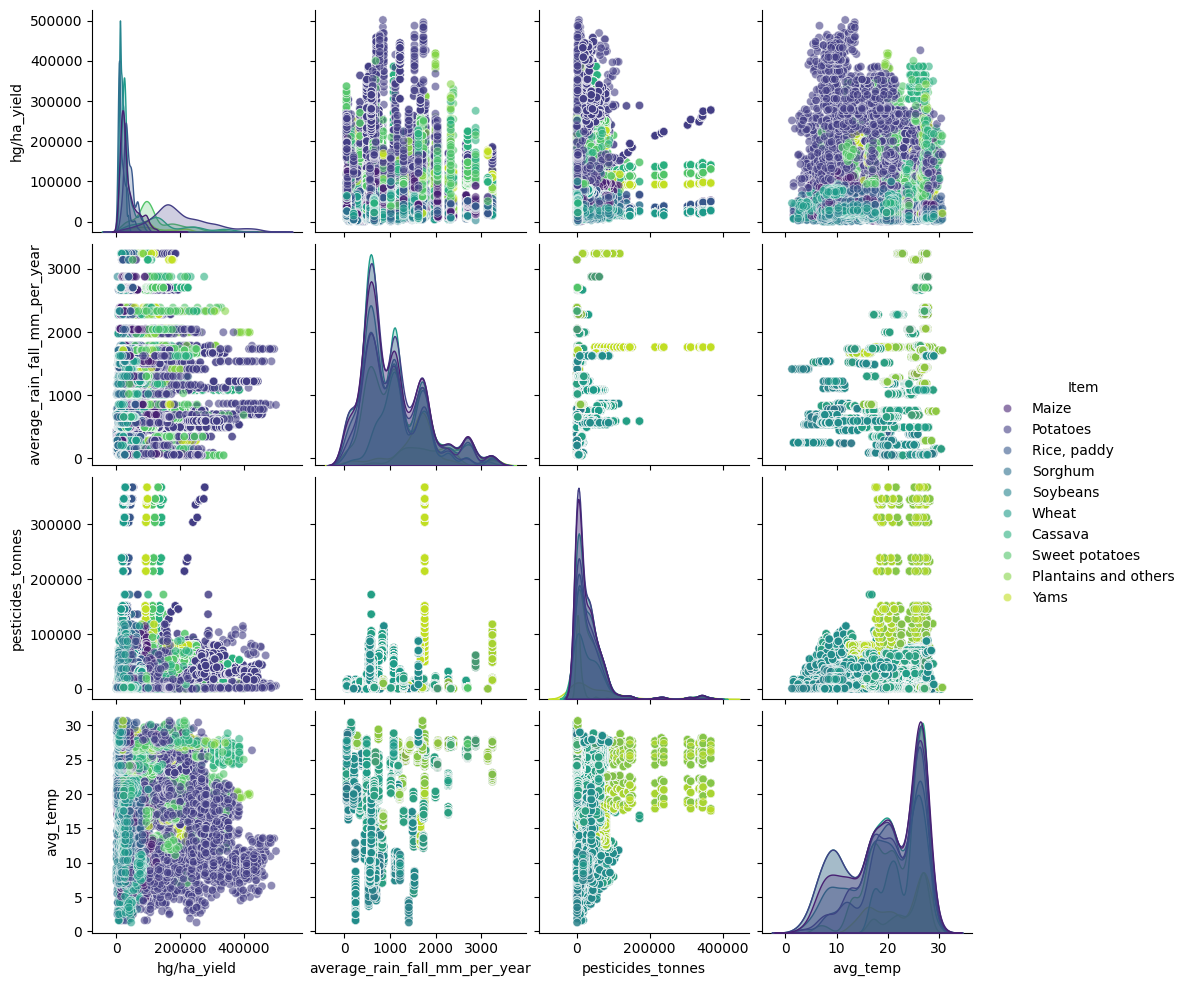

In [ ]:
sns.pairplot(
    data, 
    hue='Item', 
    vars=['hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp'],
    palette='viridis',
    diag_kind='kde',
    plot_kws={'alpha': 0.6}
)

plt.show()

### Feature Engineering

In [30]:
encoder = TargetEncoder(cols=['Area', 'Item'])
data[['Area','Item']] = encoder.fit_transform(data[['Area', 'Item']], data['hg/ha_yield'])

In [31]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Area                           28242 non-null  float64
 1   Item                           28242 non-null  float64
 2   Year                           28242 non-null  int64  
 3   hg/ha_yield                    28242 non-null  int64  
 4   average_rain_fall_mm_per_year  28242 non-null  float64
 5   pesticides_tonnes              28242 non-null  float64
 6   avg_temp                       28242 non-null  float64
dtypes: float64(5), int64(2)
memory usage: 1.5 MB


Model Selection

In [33]:
X = data.drop(columns = 'hg/ha_yield')
y = data['hg/ha_yield']

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

In [37]:
scaler = RobustScaler()
X_Train = scaler.fit_transform(X_train)

Linear Regression

In [40]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [50]:
train_preds = lr_model.predict(X_train)
test_preds = lr_model.predict(X_test)

print(f"Training R2 score: {r2_score(y_train, train_preds)}")
print(f"Testing R2 score: {r2_score(y_test, test_preds)}")

print(f"Training MAE score: {mean_absolute_error(y_train, train_preds)}")
print(f"Testing MAE score: {mean_absolute_error(y_test, test_preds)}")

print(f"Training MSE score: {mean_squared_error(y_train, train_preds)}")
print(f"Testing MSE score: {mean_squared_error(y_test, test_preds)}")

print(f"Training RMSE score: {root_mean_squared_error(y_train, train_preds)}")
print(f"Testing RMSE score: {root_mean_squared_error(y_test, test_preds)}")

Training R2 score: 0.7363134388046364
Testing R2 score: 0.7423208116694464
Training MAE score: 29198.7960204595
Testing MAE score: 29042.023425058953
Training MSE score: 1900730235.476776
Testing MSE score: 1869120305.8686543
Training RMSE score: 43597.36500611907
Testing RMSE score: 43233.32402058225


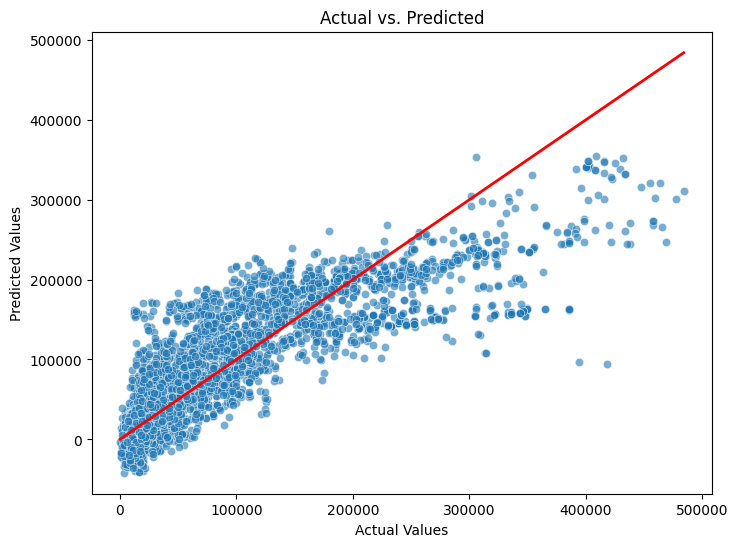

In [72]:
y_pred = lr_model.predict(X_test)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted')
plt.show()

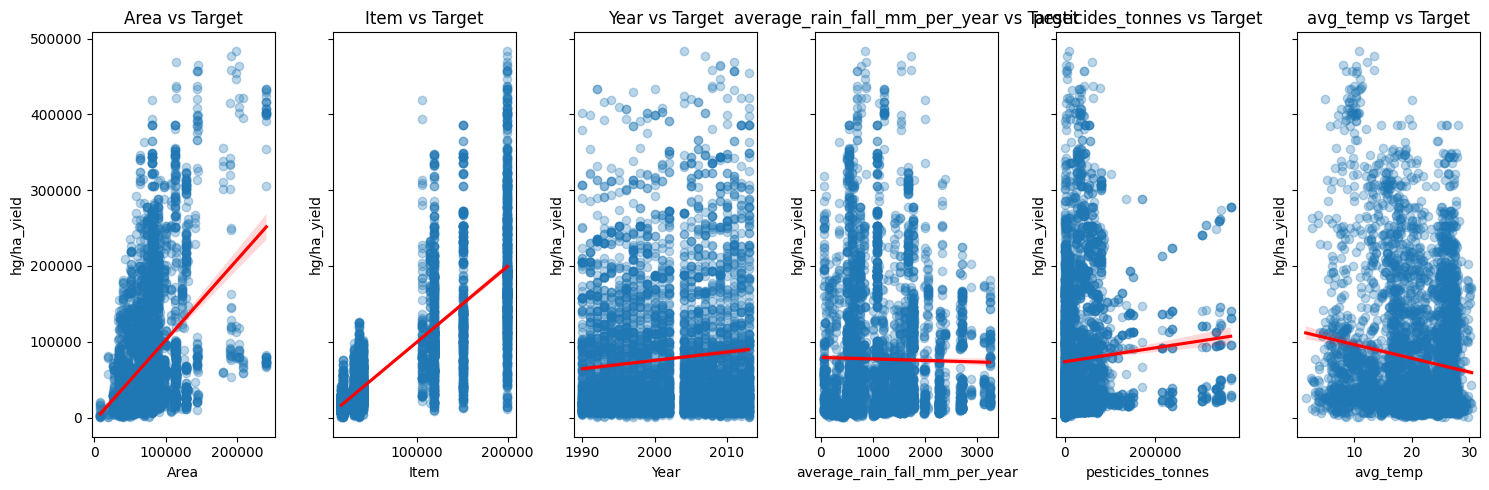

In [65]:
features = X_test.columns
fig, axes = plt.subplots(nrows=1, ncols=len(features), figsize=(15, 5), sharey=True)

for i, col in enumerate(features):
    sns.regplot(x=X_test[col], y=y_test, ax=axes[i], scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
    axes[i].set_title(f'{col} vs Target')

plt.tight_layout()

Text(0.5, 1.0, 'Residual Plot')

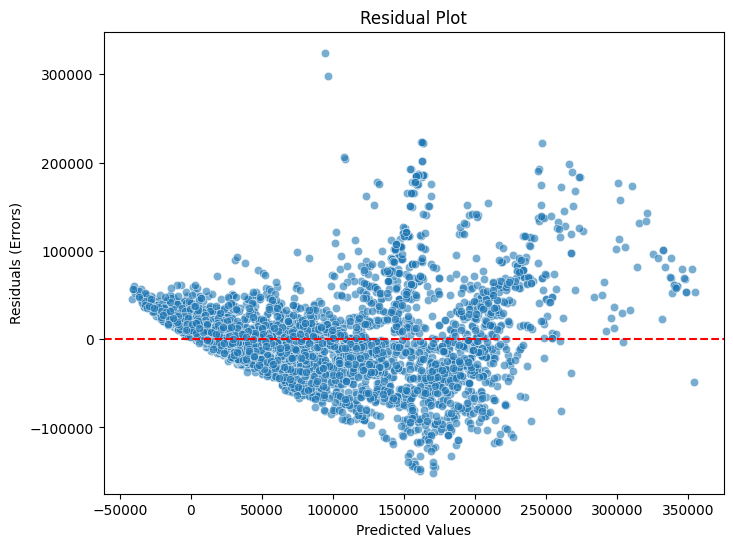

In [55]:
residuals = y_test - test_preds

plt.figure(figsize=(8, 6))
plt.axhline(y=0, color='red', linestyle='--')
sns.scatterplot(x=test_preds, y=residuals, alpha=0.6)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Errors)')
plt.title('Residual Plot')

Polynomial Regression

In [74]:
poly = PolynomialFeatures(degree = 2)
X_poly = poly.fit_transform(X_train)

In [76]:
poly_model = LinearRegression()
poly_model.fit(X_poly,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [77]:
y_poly_pred = poly_model.predict(poly.transform(X_test))

In [81]:
train_preds_poly = poly_model.predict(X_poly)
test_preds_poly = poly_model.predict(poly.transform(X_test))

print(f"Training R2 score: {r2_score(y_train, train_preds_poly)}")
print(f"Testing R2 score: {r2_score(y_test, test_preds_poly)}")

print(f"Training MAE score: {mean_absolute_error(y_train, train_preds_poly)}")
print(f"Testing MAE score: {mean_absolute_error(y_test, test_preds_poly)}")

print(f"Training MSE score: {mean_squared_error(y_train, train_preds_poly)}")
print(f"Testing MSE score: {mean_squared_error(y_test, test_preds_poly)}")

print(f"Training RMSE score: {root_mean_squared_error(y_train, train_preds_poly)}")
print(f"Testing RMSE score: {root_mean_squared_error(y_test, test_preds_poly)}")

Training R2 score: 0.8227695509608933
Testing R2 score: 0.8291232042149803
Training MAE score: 22483.269989637523
Testing MAE score: 22250.23161680446
Training MSE score: 1277529167.996442
Testing MSE score: 1239484224.0570686
Training RMSE score: 35742.54003280184
Testing RMSE score: 35206.30943534225


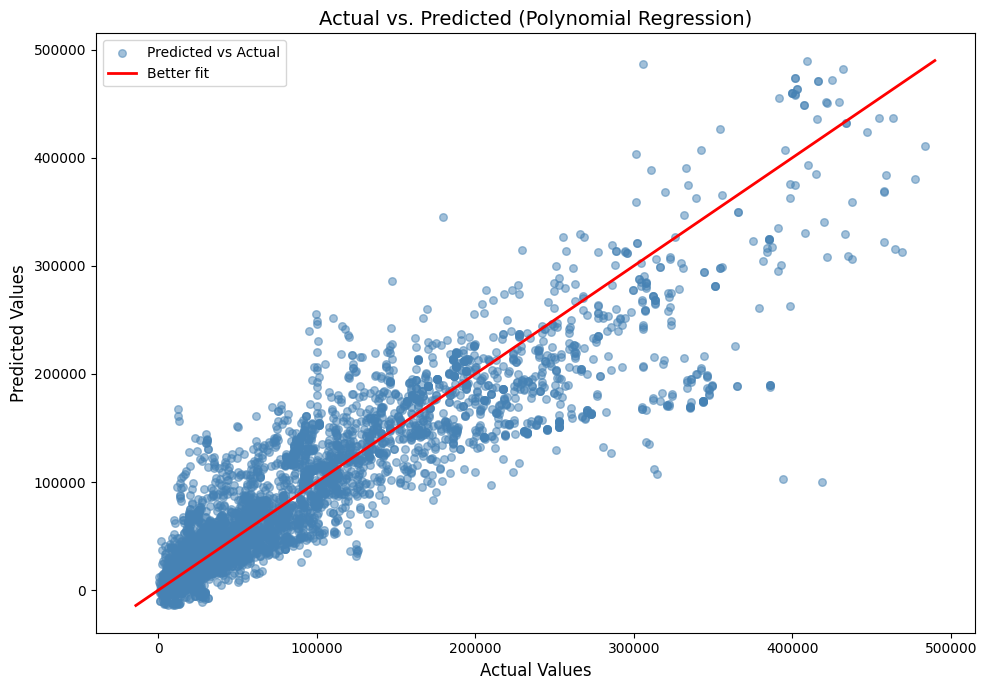

In [80]:
sorted_indices = np.argsort(y_test)
y_sorted = np.array(y_test)[sorted_indices]
y_poly_pred_sorted = np.array(y_poly_pred)[sorted_indices]

plt.figure(figsize=(10, 7))

plt.scatter(y_sorted, y_poly_pred_sorted, color='steelblue', alpha=0.5, s=30, label='Predicted vs Actual')

min_val = min(y_sorted.min(), y_poly_pred_sorted.min())
max_val = max(y_sorted.max(), y_poly_pred_sorted.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linewidth=2, label='Better fit')

plt.title('Actual vs. Predicted (Polynomial Regression)', fontsize=14)
plt.xlabel('Actual Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

Ridge Regularization

In [90]:
ridge_model = Pipeline([
    ('poly', PolynomialFeatures(degree=3)),
    ('scaler_post_poly', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('poly', ...), ('scaler_post_poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",3
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [91]:
train_preds_ridge = ridge_model.predict(X_train)
test_preds_ridge = ridge_model.predict(X_test)

print(f"Training R2 score: {r2_score(y_train, train_preds_ridge)}")
print(f"Testing R2 score: {r2_score(y_test, test_preds_ridge)}")

print(f"Training MAE score: {mean_absolute_error(y_train, train_preds_ridge)}")
print(f"Testing MAE score: {mean_absolute_error(y_test, test_preds_ridge)}")

print(f"Training MSE score: {mean_squared_error(y_train, train_preds_ridge)}")
print(f"Testing MSE score: {mean_squared_error(y_test, test_preds_ridge)}")

print(f"Training RMSE score: {root_mean_squared_error(y_train, train_preds_ridge)}")
print(f"Testing RMSE score: {root_mean_squared_error(y_test, test_preds_ridge)}")

Training R2 score: 0.8433572063042238
Testing R2 score: 0.8485524739899746
Training MAE score: 20576.861918626335
Testing MAE score: 20381.970153420298
Training MSE score: 1129127297.187217
Testing MSE score: 1098550674.4758127
Training RMSE score: 33602.48944925386
Testing RMSE score: 33144.39129740977


Lasso Regularization

In [98]:
lasso_model = Pipeline([
    ('poly', PolynomialFeatures(degree=3)),
    ('scaler_post_poly', StandardScaler()),
    ('lasso', Lasso(alpha=1.0))
])

lasso_model.fit(X_train, y_train)

c:\Users\victo\OneDrive\Documents\Data science course\Machine-Learning-Capstone\env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.313e+13, tolerance: 1.629e+10
  model = cd_fast.enet_coordinate_descent(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('poly', ...), ('scaler_post_poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",3
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [99]:
train_preds_lasso = lasso_model.predict(X_train)
test_preds_lasso = lasso_model.predict(X_test)

print(f"Training R2 score: {r2_score(y_train, train_preds_lasso)}")
print(f"Testing R2 score: {r2_score(y_test, test_preds_lasso)}")

Training R2 score: 0.835424080585176
Testing R2 score: 0.8418909949745257
